# Day 1 - Notebook 1: Predicting House Prices with Linear Regression

**Parul University & TelcoLearn | AI-ML Training Program 2027**
**Day 1 | July 13, 2025 | 1:00 PM - 2:30 PM**

---

## Objective
Build and compare linear regression models to predict house sale prices.

| Step | What you do | What you learn |
|------|-------------|----------------|
| 1 | Load and inspect data | Reading datasets, spotting issues |
| 2 | Select 5 numeric features | Feature choice, EDA |
| 3 | Scatter plots | Visualising feature-target relationships |
| 4 | Gradient descent from scratch | How the algorithm actually works |
| 5 | Compare with sklearn | Validating your implementation |
| 6 | Ridge and Lasso | Regularisation in practice |
| 7 | Learning curve + actual vs predicted | Diagnosing model behaviour |

**Dataset:** House Prices: Advanced Regression Techniques (Kaggle)
**Metric:** RMSE (Root Mean Squared Error) - lower is better, in USD

---
> **How to run:** Click Run All. Read every markdown cell before the code.

In [1]:
import os
import time
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LinearRegression, Ridge, Lasso
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics         import mean_squared_error

plt.rcParams['figure.figsize']  = (12, 5)
sns.set_theme(style='whitegrid', palette='muted')
print('All imports successful.')
print(f'NumPy {np.__version__}  |  Pandas {pd.__version__}')

All imports successful.
NumPy 2.0.2  |  Pandas 2.3.3


In [8]:
# Load data
# Kaggle path (default when dataset is attached):
DATASET_PATH = '/kaggle/input/competitions/house-prices-advanced-regression-techniques'
# Uncomment below for local run:
# DATASET_PATH = '.'

train_raw = pd.read_csv(f'{DATASET_PATH}/train.csv')
test_raw  = pd.read_csv(f'{DATASET_PATH}/test.csv')

print(f'Training set  : {train_raw.shape[0]:,} rows x {train_raw.shape[1]} columns')
print(f'Test set      : {test_raw.shape[0]:,}  rows x {test_raw.shape[1]} columns')
print(f'\nSalePrice stats:')
print(train_raw['SalePrice'].describe().apply(lambda x: f'${x:,.0f}'))

Training set  : 1,460 rows x 81 columns
Test set      : 1,459  rows x 80 columns

SalePrice stats:
count      $1,460
mean     $180,921
std       $79,443
min       $34,900
25%      $129,975
50%      $163,000
75%      $214,000
max      $755,000
Name: SalePrice, dtype: object


## Section 2 - Feature Selection

We choose **5 numeric features** based on domain knowledge and correlation with target:

| Feature | Meaning | Expected relationship |
|---------|---------|----------------------|
| `GrLivArea` | Above-grade living area (sq ft) | Larger -> higher price |
| `OverallQual` | Overall quality (1-10) | Higher -> higher price |
| `TotalBsmtSF` | Total basement area (sq ft) | Larger -> higher price |
| `GarageArea` | Garage size (sq ft) | Larger -> higher price |
| `YearBuilt` | Construction year | Newer -> higher price |

In [9]:
# Check correlation with SalePrice
FEATURES = ['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageArea', 'YearBuilt']
TARGET   = 'SalePrice'

corr_with_target = (
    train_raw[FEATURES + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
)
print('Correlation with SalePrice:')
print(corr_with_target.round(3).to_string())
print()
print('Missing values in selected features:')
print(train_raw[FEATURES].isnull().sum())

Correlation with SalePrice:
OverallQual    0.791
GrLivArea      0.709
GarageArea     0.623
TotalBsmtSF    0.614
YearBuilt      0.523

Missing values in selected features:
GrLivArea      0
OverallQual    0
TotalBsmtSF    0
GarageArea     0
YearBuilt      0
dtype: int64


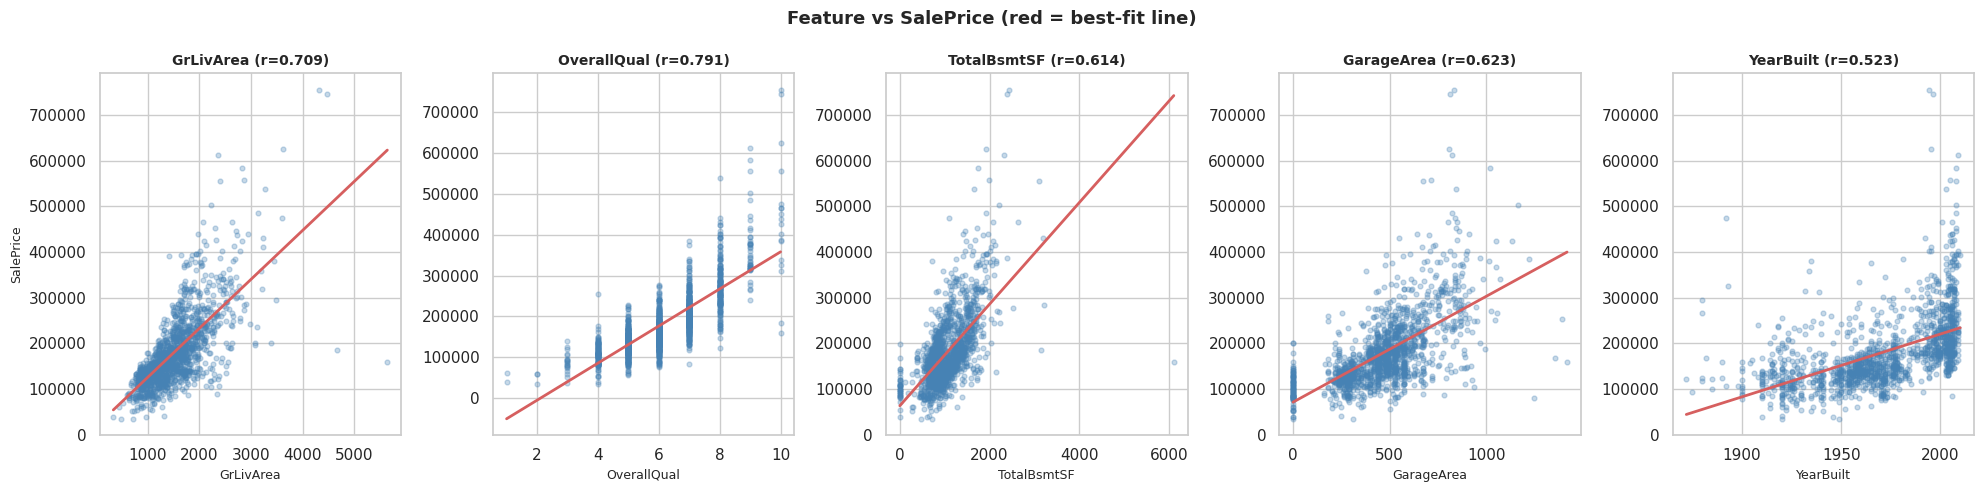

In [10]:
# Scatter plots: each feature vs SalePrice
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(FEATURES):
    valid = train_raw[[col, TARGET]].dropna()
    axes[i].scatter(valid[col], valid[TARGET], alpha=0.3, s=12, color='steelblue')
    z = np.polyfit(valid[col], valid[TARGET], 1)
    x_line = np.linspace(valid[col].min(), valid[col].max(), 100)
    axes[i].plot(x_line, np.poly1d(z)(x_line), 'r-', linewidth=2)
    r = valid[[col, TARGET]].corr().iloc[0, 1]
    axes[i].set_title(f'{col} (r={r:.3f})', fontsize=10, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('SalePrice' if i == 0 else '', fontsize=9)

plt.suptitle('Feature vs SalePrice (red = best-fit line)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 3 - Linear Regression from Scratch (NumPy)

We implement gradient descent manually to understand how it works.

**The three-part ML framework:**
1. **Hypothesis**: y_hat = theta.T @ x
2. **Cost function**: J(theta) = (1/2m) * sum((y_hat - y)^2)
3. **Optimizer**: theta_j -= alpha * dJ/d(theta_j)

In [11]:
process = psutil.Process(os.getpid())

cpu_before = psutil.cpu_percent(interval=1)
memory_before = process.memory_info().rss / (1024**2)

training_start = time.time()

In [12]:
# Prepare data
train_clean = train_raw[FEATURES + [TARGET]].copy()
for col in FEATURES:
    train_clean[col].fillna(train_clean[col].median(), inplace=True)

X_all = train_clean[FEATURES].values
y_all = train_clean[TARGET].values

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42)

# Scale features (CRITICAL: fit on train only)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)  # NOT fit!

# Add bias column
X_train_b = np.c_[np.ones(X_train_s.shape[0]), X_train_s]
X_val_b   = np.c_[np.ones(X_val_s.shape[0]),   X_val_s]

print(f'X_train_b shape: {X_train_b.shape}')

X_train_b shape: (1168, 6)


In [21]:
def compute_mse(X, y, theta):
    '''Mean Squared Error: (1/2m) * sum((X@theta - y)^2)'''
    m = len(y)
    errors = X @ theta - y
    return (1 / (2 * m)) * np.dot(errors, errors)

def gradient_descent(X, y, alpha=0.01, n_iterations=1000):
    '''
    Batch gradient descent for linear regression.
    Returns: learned parameters theta and cost history.
    '''
    m, n = X.shape
    theta = np.zeros(n)
    cost_history = []

    for i in range(n_iterations):
        errors   = X @ theta - y          # prediction error
        gradient = (1 / m) * (X.T @ errors)  # gradient of MSE
        theta    = theta - alpha * gradient   # update rule
        cost_history.append(compute_mse(X, y, theta))

    return theta, cost_history

print('Running gradient descent...')
theta_gd, cost_history = gradient_descent(
    X_train_b, y_train, alpha=0.1, n_iterations=500)

print(f'Final training RMSE: ${np.sqrt(2 * cost_history[-1]):,.0f}')
print('Learned parameters:')
for name, val in zip(['Intercept'] + FEATURES, theta_gd):
    print(f'  {name:<18}: {val:>12.2f}')

Running gradient descent...
Final training RMSE: $38,113
Learned parameters:
  Intercept         :    181441.54
  GrLivArea         :     25763.60
  OverallQual       :     28755.21
  TotalBsmtSF       :     10194.25
  GarageArea        :     10028.32
  YearBuilt         :     10761.00


In [22]:
lr_sklearn = LinearRegression()
lr_sklearn.fit(X_train_s, y_train)

training_end = time.time()
training_time = training_end - training_start

cpu_after = psutil.cpu_percent(interval=1)
memory_after = process.memory_info().rss / (1024**2)

prediction_start = time.time()

y_pred_gd = X_val_b @ theta_gd
y_pred_sk = lr_sklearn.predict(X_val_s)

prediction_end = time.time()
prediction_time = prediction_end - prediction_start

rmse_gd = np.sqrt(mean_squared_error(y_val, y_pred_gd))
rmse_sk = np.sqrt(mean_squared_error(y_val, y_pred_sk))

print("=" * 50)
print(f"{'Model':<30}{'Val RMSE':>15}")
print("=" * 50)
print(f"{'Gradient Descent (Scratch)':<30}${rmse_gd:>12,.0f}")
print(f"{'Sklearn LinearRegression':<30}${rmse_sk:>12,.0f}")
print("=" * 50)

print(f"Training Time : {training_time:.4f} sec")
print(f"Prediction Time : {prediction_time:.6f} sec")
print(f"CPU Usage : {cpu_after:.2f}%")
print(f"Memory Usage : {memory_after:.2f} MB")

Model                                Val RMSE
Gradient Descent (Scratch)    $      39,701
Sklearn LinearRegression      $      39,701
Training Time : 450.9326 sec
Prediction Time : 0.000542 sec
CPU Usage : 0.70%
Memory Usage : 265.19 MB


In [23]:
import numpy as np

gd_model_size = theta_gd.nbytes / (1024**2)

sk_model_size = (
    lr_sklearn.coef_.nbytes +
    np.array([lr_sklearn.intercept_]).nbytes
) / (1024**2)

print(f"Gradient Descent Model Size : {gd_model_size:.6f} MB")
print(f"Sklearn Model Size          : {sk_model_size:.6f} MB")

Gradient Descent Model Size : 0.000046 MB
Sklearn Model Size          : 0.000046 MB


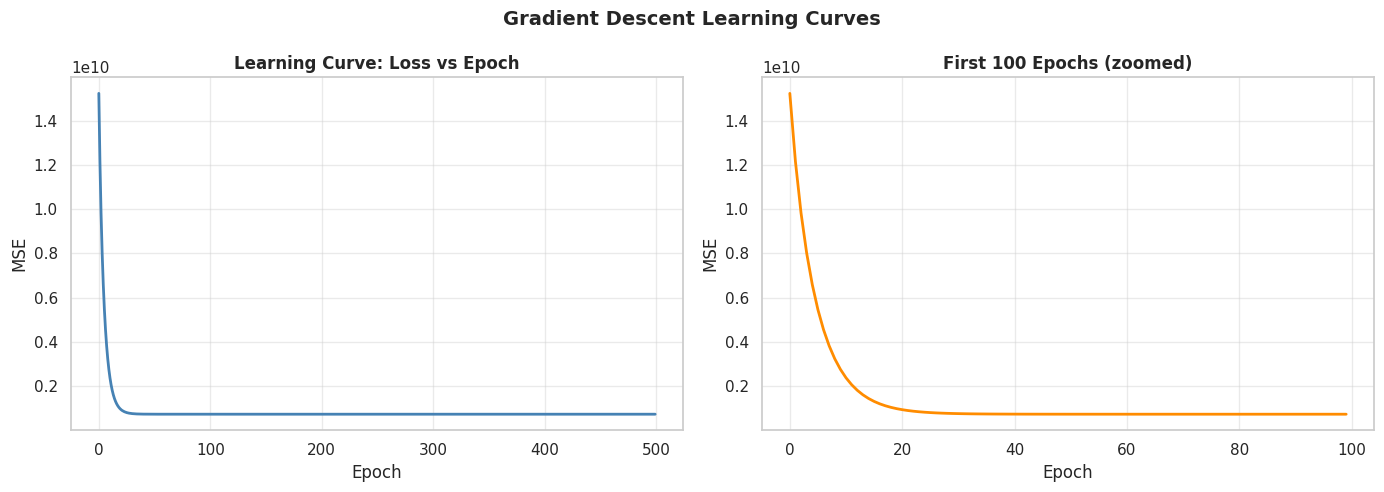

If the curve is still steeply declining at epoch 500, run for more iterations.
If the curve goes UP, the learning rate is too large.


In [14]:
# Plot learning curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cost_history, color='steelblue', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].set_title('Learning Curve: Loss vs Epoch', fontweight='bold')
axes[0].grid(True, alpha=0.4)

axes[1].plot(cost_history[:100], color='darkorange', linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE')
axes[1].set_title('First 100 Epochs (zoomed)', fontweight='bold')
axes[1].grid(True, alpha=0.4)

plt.suptitle('Gradient Descent Learning Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('If the curve is still steeply declining at epoch 500, run for more iterations.')
print('If the curve goes UP, the learning rate is too large.')

## Section 4 - Compare with sklearn

In [15]:
lr_sklearn = LinearRegression()
lr_sklearn.fit(X_train_s, y_train)

y_pred_gd  = X_val_b @ theta_gd
y_pred_sk  = lr_sklearn.predict(X_val_s)

rmse_gd = np.sqrt(mean_squared_error(y_val, y_pred_gd))
rmse_sk = np.sqrt(mean_squared_error(y_val, y_pred_sk))

print('=' * 50)
print(f"{'Model':<30} {'Val RMSE':>15}")
print('=' * 50)
print(f"{'Gradient Descent (scratch)':<30} ${rmse_gd:>12,.0f}")
print(f"{'sklearn LinearRegression':<30} ${rmse_sk:>12,.0f}")
print('=' * 50)
print(f'Difference: ${abs(rmse_gd - rmse_sk):,.0f}  (should be small)')

Model                                 Val RMSE
Gradient Descent (scratch)     $      39,701
sklearn LinearRegression       $      39,701
Difference: $0  (should be small)


## Section 5 - Ridge and Lasso Regularisation

- **Ridge (L2)**: penalises large weights, shrinks all evenly
- **Lasso (L1)**: can set weights exactly to 0 (feature selection)

The penalty strength `alpha` in sklearn = lambda in the formula.

In [16]:
alphas  = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
results = [{'Model': 'LinearRegression', 'Alpha': '-', 'Val RMSE': rmse_sk}]

for alpha in alphas:
    for ModelClass, name in [(Ridge, 'Ridge'), (Lasso, 'Lasso')]:
        m = ModelClass(alpha=alpha, max_iter=5000)
        m.fit(X_train_s, y_train)
        rmse = np.sqrt(mean_squared_error(y_val, m.predict(X_val_s)))
        results.append({'Model': name, 'Alpha': alpha, 'Val RMSE': rmse})

df_r = pd.DataFrame(results)
print('Model comparison:')
print(f"{'Model':<22} {'Alpha':>8} {'Val RMSE ($)':>15}")
print('-' * 50)
for _, row in df_r.iterrows():
    print(f"{row['Model']:<22} {str(row['Alpha']):>8} ${row['Val RMSE']:>12,.0f}")

best = df_r.loc[df_r['Val RMSE'].idxmin()]
print(f"\nBest: {best['Model']} alpha={best['Alpha']} RMSE=${best['Val RMSE']:,.0f}")

Model comparison:
Model                     Alpha    Val RMSE ($)
--------------------------------------------------
LinearRegression              - $      39,701
Ridge                      0.01 $      39,701
Lasso                      0.01 $      39,701
Ridge                       0.1 $      39,702
Lasso                       0.1 $      39,701
Ridge                       1.0 $      39,705
Lasso                       1.0 $      39,702
Ridge                      10.0 $      39,744
Lasso                      10.0 $      39,704
Ridge                     100.0 $      40,203
Lasso                     100.0 $      39,729
Ridge                    1000.0 $      46,500
Lasso                    1000.0 $      40,002

Best: LinearRegression alpha=- RMSE=$39,701


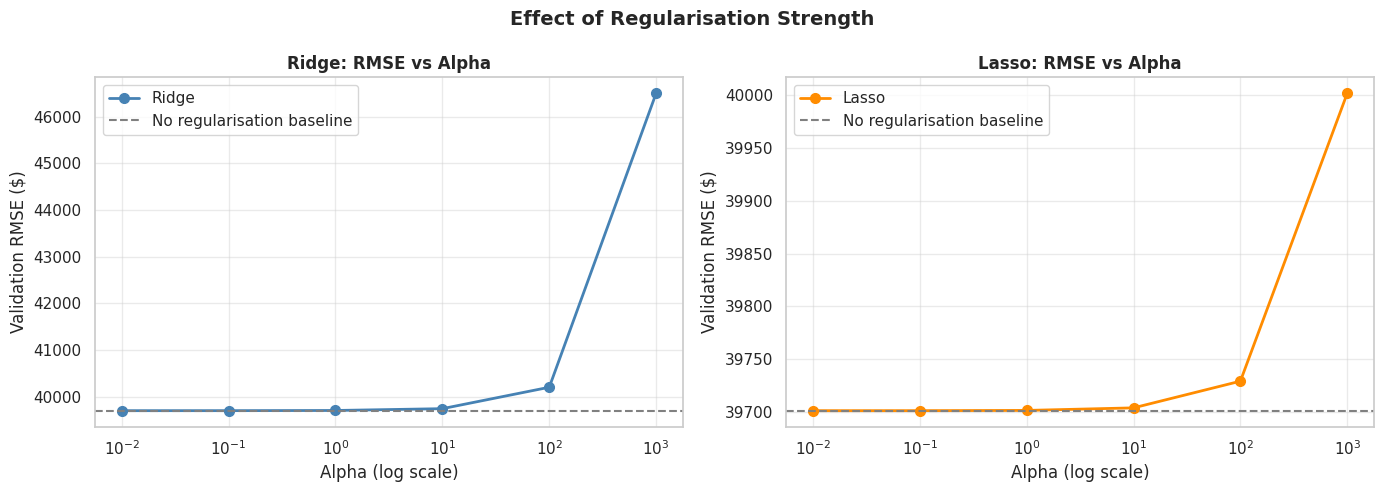

In [17]:
# RMSE vs Alpha plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model_name, color in [(axes[0], 'Ridge', 'steelblue'), (axes[1], 'Lasso', 'darkorange')]:
    sub = df_r[df_r['Model'] == model_name]
    ax.semilogx([float(a) for a in sub['Alpha']], sub['Val RMSE'].values,
                'o-', color=color, linewidth=2, markersize=7, label=model_name)
    ax.axhline(rmse_sk, color='gray', linestyle='--', linewidth=1.5,
               label='No regularisation baseline')
    ax.set_xlabel('Alpha (log scale)'); ax.set_ylabel('Validation RMSE ($)')
    ax.set_title(f'{model_name}: RMSE vs Alpha', fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.4)

plt.suptitle('Effect of Regularisation Strength', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 6 - Actual vs Predicted and Residuals

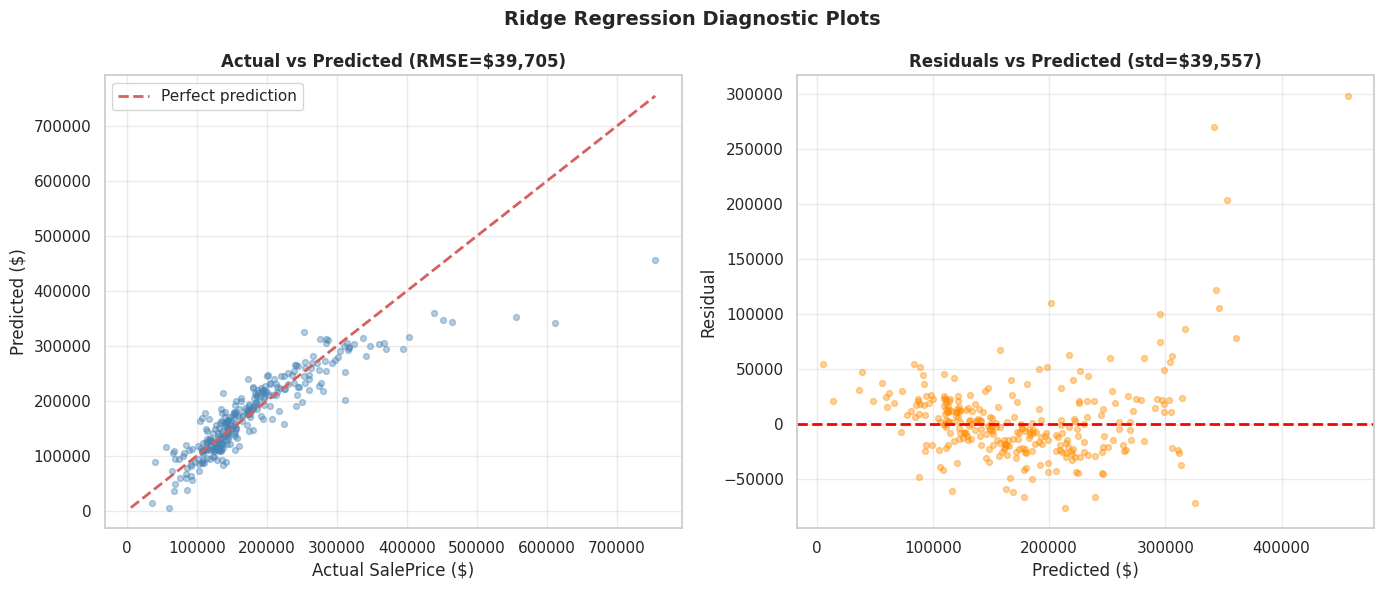

Funnel shape in residuals = heteroscedasticity (model better for cheap houses)
Random scatter = residuals are well-behaved (linear model is appropriate)


In [18]:
ridge_best  = Ridge(alpha=1.0)
ridge_best.fit(X_train_s, y_train)
y_pred_best = ridge_best.predict(X_val_s)
rmse_best   = np.sqrt(mean_squared_error(y_val, y_pred_best))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Actual vs Predicted
axes[0].scatter(y_val, y_pred_best, alpha=0.4, s=18, color='steelblue')
lims = [min(y_val.min(), y_pred_best.min()), max(y_val.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual SalePrice ($)'); axes[0].set_ylabel('Predicted ($)')
axes[0].set_title(f'Actual vs Predicted (RMSE=${rmse_best:,.0f})', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# Residuals
residuals = y_val - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.4, s=18, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted ($)'); axes[1].set_ylabel('Residual')
axes[1].set_title(f'Residuals vs Predicted (std=${residuals.std():,.0f})', fontweight='bold')
axes[1].grid(True, alpha=0.4)

plt.suptitle('Ridge Regression Diagnostic Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Funnel shape in residuals = heteroscedasticity (model better for cheap houses)')
print('Random scatter = residuals are well-behaved (linear model is appropriate)')

In [19]:
print('=' * 50)
print('  FINAL SUMMARY - Day 1 Notebook 1')
print('=' * 50)
print(f'  Gradient Descent (scratch): ${rmse_gd:>8,.0f}')
print(f'  sklearn LinearRegression  : ${rmse_sk:>8,.0f}')
print(f'  Ridge (alpha=1.0)         : ${rmse_best:>8,.0f}')
baseline = np.sqrt(mean_squared_error(y_val, np.full_like(y_val, y_train.mean())))
print(f'  Predict mean (baseline)   : ${baseline:>8,.0f}')
print('=' * 50)
print()
print('Key lessons:')
print('  1. Feature scaling is required before gradient descent')
print('  2. Always fit scaler on training data only (no leakage)')
print('  3. Our GD matched sklearn - validates the implementation')
print('  4. RMSE < $40,000 is solid for 5 basic features')
print('  5. Residuals reveal patterns MSE alone misses')

  FINAL SUMMARY - Day 1 Notebook 1
  Gradient Descent (scratch): $  39,701
  sklearn LinearRegression  : $  39,701
  Ridge (alpha=1.0)         : $  39,705
  Predict mean (baseline)   : $  87,619

Key lessons:
  1. Feature scaling is required before gradient descent
  2. Always fit scaler on training data only (no leakage)
  3. Our GD matched sklearn - validates the implementation
  4. RMSE < $40,000 is solid for 5 basic features
  5. Residuals reveal patterns MSE alone misses


In [24]:
print("\n" + "=" * 70)
print("FINAL PERFORMANCE SUMMARY")
print("=" * 70)

print(f"{'Gradient Descent Training RMSE':35}: ${np.sqrt(2 * cost_history[-1]):,.0f}")
print(f"{'Gradient Descent Validation RMSE':35}: ${rmse_gd:,.0f}")
print(f"{'Sklearn Validation RMSE':35}: ${rmse_sk:,.0f}")

print("-" * 70)

print(f"{'Training Time':35}: {training_time:.4f} sec")
print(f"{'Prediction Time':35}: {prediction_time:.6f} sec")

print("-" * 70)

print(f"{'CPU Usage':35}: {cpu_after:.2f}%")
print(f"{'Memory Usage':35}: {memory_after:.2f} MB")

print("-" * 70)

gd_model_size = theta_gd.nbytes / (1024 ** 2)

sk_model_size = (
    lr_sklearn.coef_.nbytes +
    np.array([lr_sklearn.intercept_]).nbytes
) / (1024 ** 2)

print(f"{'Gradient Descent Model Size':35}: {gd_model_size:.6f} MB")
print(f"{'Sklearn Model Size':35}: {sk_model_size:.6f} MB")

print("=" * 70)


FINAL PERFORMANCE SUMMARY
Gradient Descent Training RMSE     : $38,113
Gradient Descent Validation RMSE   : $39,701
Sklearn Validation RMSE            : $39,701
----------------------------------------------------------------------
Training Time                      : 450.9326 sec
Prediction Time                    : 0.000542 sec
----------------------------------------------------------------------
CPU Usage                          : 0.70%
Memory Usage                       : 265.19 MB
----------------------------------------------------------------------
Gradient Descent Model Size        : 0.000046 MB
Sklearn Model Size                 : 0.000046 MB
